# Chapter 1 — What a Vector Really Is

Linear algebra is the study of **vector spaces** and the **linear transformations**
that map one space to another. That one sentence contains the whole course, and
this chapter builds the first half of it.

You probably met vectors as arrows in physics, or as lists of numbers in a
programming course. Both pictures are correct and both are too small. The
definition that does the real work is this:

> A **vector** is an element of a vector space: an object you can **add** to
> another object of the same kind, and **scale** by a number, such that the
> results stay in the same collection and behave sensibly.

That is deliberately vague about what the object *is*, and the payoff for the
vagueness is enormous. Polynomials, functions, matrices, and 28×28 images all
qualify, so every theorem and every algorithm you learn from here on applies to
all of them at once. By the end of this notebook you will have run the *same*
line of code on arrows, curves, and photographs of handwriting.

| Module | What you build | Data |
|---|---|---|
| I | The two operations, drawn: addition as a parallelogram, scaling as a stretch | — |
| II | An **axiom checker**: all eight axioms tested numerically, on a real vector space, a disguised one, and a fake | — |
| III | The same operations on **polynomials, functions, and 784-dimensional images** | `ylecun/mnist` |
| IV | A **subspace detector**: the closure tests that separate genuine subspaces from impostors | — |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** a few seconds on CPU. MNIST is an ~11 MB download the first time
and comes from a local cache after that.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — Two Operations, and Nothing Else

## I.a The picture you already have

🧠 **The intuition.** A vector in the plane is a displacement: "go 3 right and 1
up". Two displacements *add* by doing one after the other, which is why the sum
lands on the far corner of a parallelogram. Scaling by 2 means "do the same
thing, twice as far"; scaling by $-1$ means "do it backwards".

Everything in this course is built out of exactly those two moves. There is no
third operation. Notice what is *missing*: there is no way to multiply two
vectors together, and no way to divide. (The dot product arrives in Chapter 7,
and it is not vector multiplication: it eats two vectors and returns a
*number*.)

📐 **The math.** $\mathbb{R}^n$ is the set of ordered $n$-tuples of real numbers,
with both operations defined **componentwise**:

$$ \mathbf{u} + \mathbf{v} = \begin{bmatrix} u_1 + v_1 \\ \vdots \\ u_n + v_n \end{bmatrix},
\qquad
c\,\mathbf{v} = \begin{bmatrix} c\,v_1 \\ \vdots \\ c\,v_n \end{bmatrix} $$

💻 **The code.** In NumPy those two definitions are `+` and `*`, and the
componentwise rule is exactly what broadcasting already does.

In [2]:
u = np.array([3.0, 1.0])
v = np.array([1.0, 2.0])

print("u       =", u)
print("v       =", v)
print("u + v   =", u + v)
print("2 * u   =", 2 * u)
print("-1 * v  =", -1 * v)
print("2u - v  =", 2 * u - v)      # any combination of the two moves is legal

u       = [3. 1.]
v       = [1. 2.]
u + v   = [4. 3.]
2 * u   = [6. 2.]
-1 * v  = [-1. -2.]
2u - v  = [5. 0.]


Drawn, addition is a parallelogram and scaling slides a vector along the line
through the origin that it defines. That line, every scalar multiple of a single
vector, is the smallest interesting object in linear algebra, and in Chapter 2
it gets a name: the *span* of $\mathbf{v}$.

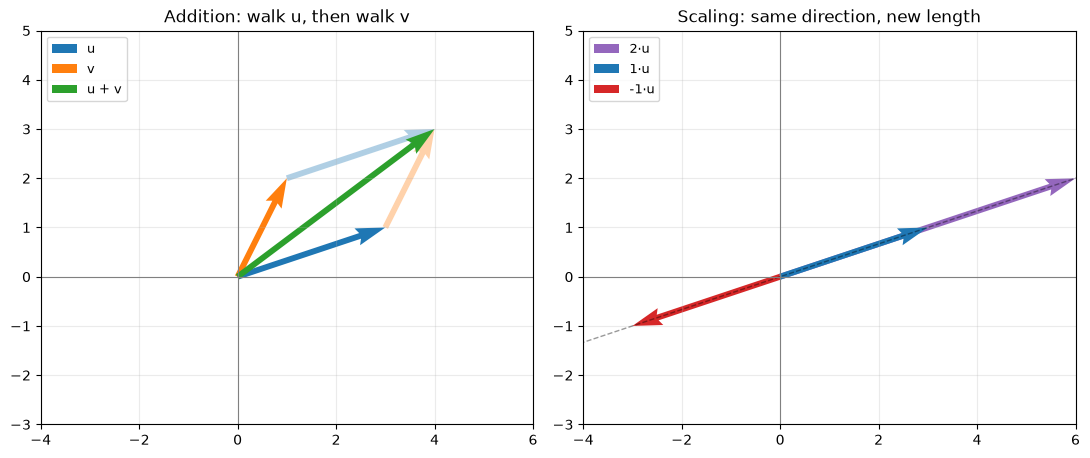

In [3]:
def draw_vec(ax, vec, color, label, start=(0, 0), **kw):
    """Draw `vec` as an arrow starting at `start`."""
    ax.quiver(*start, *vec, angles="xy", scale_units="xy", scale=1,
              color=color, width=0.012, label=label, **kw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# --- left: addition as a parallelogram -----------------------------------
ax = axes[0]
draw_vec(ax, u, "tab:blue", "u")
draw_vec(ax, v, "tab:orange", "v")
draw_vec(ax, v, "tab:orange", None, start=u, alpha=0.35)   # v, moved to the tip of u
draw_vec(ax, u, "tab:blue", None, start=v, alpha=0.35)
draw_vec(ax, u + v, "tab:green", "u + v")
ax.set_title("Addition: walk u, then walk v")

# --- right: scaling slides along one line --------------------------------
ax = axes[1]
line = np.array([[-1.5, 2.5]]).T * u                        # the whole line through u
ax.plot(line[:, 0], line[:, 1], "k--", alpha=0.4, lw=1)
for c, color in [(2.0, "tab:purple"), (1.0, "tab:blue"), (-1.0, "tab:red")]:
    draw_vec(ax, c * u, color, f"{c:g}·u")
ax.set_title("Scaling: same direction, new length")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlim(-4, 6); ax.set_ylim(-3, 5); ax.set_aspect("equal")
    ax.grid(alpha=0.25); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## I.b The arrow is a picture, not the definition

Nothing in the code above cared that $n = 2$. Try it with $n = 784$ and every
line still works. You simply lose the ability to draw it. That is the first
hint that the arrow is a *visual aid* for a definition that does not mention
geometry at all.

What that definition rests on instead is a list of rules the two operations must
*obey*.

---
# Module II — The Eight Axioms

## II.a What a vector space actually is

🧠 **The intuition.** A vector space is a **collection of objects plus two
operations**, where the operations never take you outside the collection and
never surprise you. "Never surprise you" is the part that needs pinning down:
it means the arithmetic behaves the way school algebra taught you it should,
so order does not matter for addition, parentheses do not matter, there is a
"nothing" element, and multiplying by 1 does nothing.

📐 **The math.** A set $V$ with an addition $V \times V \to V$ and a scalar
multiplication $\mathbb{R} \times V \to V$ is a **vector space** if, for all
$\mathbf{u}, \mathbf{v}, \mathbf{w} \in V$ and all scalars $c, d$:

| # | Axiom | Name |
|---|---|---|
| 1 | $\mathbf{u} + \mathbf{v} = \mathbf{v} + \mathbf{u}$ | commutativity |
| 2 | $(\mathbf{u} + \mathbf{v}) + \mathbf{w} = \mathbf{u} + (\mathbf{v} + \mathbf{w})$ | associativity |
| 3 | there is a $\mathbf{0} \in V$ with $\mathbf{v} + \mathbf{0} = \mathbf{v}$ | additive identity |
| 4 | for each $\mathbf{v}$ there is a $-\mathbf{v}$ with $\mathbf{v} + (-\mathbf{v}) = \mathbf{0}$ | additive inverse |
| 5 | $c(\mathbf{u} + \mathbf{v}) = c\mathbf{u} + c\mathbf{v}$ | distributivity over vector addition |
| 6 | $(c + d)\mathbf{v} = c\mathbf{v} + d\mathbf{v}$ | distributivity over scalar addition |
| 7 | $c(d\mathbf{v}) = (cd)\mathbf{v}$ | compatibility of scalars |
| 8 | $1\,\mathbf{v} = \mathbf{v}$ | scalar identity |

The two arrows in "$V \times V \to V$" carry a requirement of their own, called
**closure**: the sum of two members is a member, and a scalar multiple of a
member is a member. Half the work in this notebook is checking closure, because
it is the axiom that fails most often in practice.

💻 **The code.** The axioms are testable. Feed a checker an `add`, a `smul`, and
a way to draw random members, and it can look for a counterexample.

In [4]:
N_TRIALS = 200          # <- knob: random (u, v, w, c, d) draws per axiom
TOL = 1e-9              # <- knob: floating-point slack for "equal"

def check_axioms(sample, add, smul, zero, neg, n_trials=N_TRIALS, tol=TOL):
    """Look for a counterexample to each of the eight axioms.

    sample() -> a random member of the candidate space
    add(u, v), smul(c, v), neg(v) -> the candidate operations
    zero -> the proposed additive identity
    Returns {axiom name: True if no counterexample was found}.
    """
    eq = lambda a, b: np.allclose(a, b, atol=tol, rtol=0)
    results = {}

    def trial(name, test):
        results[name] = all(test() for _ in range(n_trials))

    trial("1. u + v = v + u",           lambda: (lambda u, v: eq(add(u, v), add(v, u)))(sample(), sample()))
    trial("2. (u+v)+w = u+(v+w)",       lambda: (lambda u, v, w: eq(add(add(u, v), w), add(u, add(v, w))))(sample(), sample(), sample()))
    trial("3. v + 0 = v",               lambda: (lambda v: eq(add(v, zero), v))(sample()))
    trial("4. v + (-v) = 0",            lambda: (lambda v: eq(add(v, neg(v)), zero))(sample()))
    trial("5. c(u+v) = cu + cv",        lambda: (lambda u, v, c: eq(smul(c, add(u, v)), add(smul(c, u), smul(c, v))))(sample(), sample(), rng.normal()))
    trial("6. (c+d)v = cv + dv",        lambda: (lambda v, c, d: eq(smul(c + d, v), add(smul(c, v), smul(d, v))))(sample(), rng.normal(), rng.normal()))
    trial("7. c(dv) = (cd)v",           lambda: (lambda v, c, d: eq(smul(c, smul(d, v)), smul(c * d, v)))(sample(), rng.normal(), rng.normal()))
    trial("8. 1v = v",                  lambda: (lambda v: eq(smul(1.0, v), v))(sample()))
    return results


def report(name, results):
    verdict = "IS a vector space" if all(results.values()) else "is NOT a vector space"
    print(f"{name}  ->  {verdict}")
    for axiom, ok in results.items():
        print(f"    {'PASS' if ok else 'FAIL'}  {axiom}")
    print()

## II.b Case 1: $\mathbb{R}^3$, the space you expect

The reference case. Ordinary addition, ordinary scaling, zero vector
$(0,0,0)$.

In [5]:
report("R^3, standard operations", check_axioms(
    sample=lambda: rng.normal(size=3),
    add=lambda u, v: u + v,
    smul=lambda c, v: c * v,
    zero=np.zeros(3),
    neg=lambda v: -v,
))

R^3, standard operations  ->  IS a vector space
    PASS  1. u + v = v + u
    PASS  2. (u+v)+w = u+(v+w)
    PASS  3. v + 0 = v
    PASS  4. v + (-v) = 0
    PASS  5. c(u+v) = cu + cv
    PASS  6. (c+d)v = cv + dv
    PASS  7. c(dv) = (cd)v
    PASS  8. 1v = v



## II.c Case 2: a vector space in disguise

Here is a collection that looks nothing like arrows: the **positive** real
numbers, where "addition" means *multiply* and "scaling by $c$" means *raise to
the power $c$*:

$$ u \oplus v = uv, \qquad c \odot v = v^{\,c} $$

The additive identity cannot be $0$, which is not even in the set. It must be
the number that does nothing under multiplication, namely $\mathbf{0} = 1$. The
"negative" of $v$ is $1/v$.

This looks like a party trick, and it is not: it is the reason log-scales work,
and the reason multiplicative quantities (odds, growth rates, prices) become
additive after a logarithm. Run the checker before deciding whether it counts.

In [6]:
report("Positive reals, u+v := u*v and c*v := v**c", check_axioms(
    sample=lambda: np.exp(rng.normal(size=3)),      # positive numbers only
    add=lambda u, v: u * v,
    smul=lambda c, v: v ** c,
    zero=np.ones(3),                                 # 1 is the "zero vector" here
    neg=lambda v: 1.0 / v,
))

Positive reals, u+v := u*v and c*v := v**c  ->  IS a vector space
    PASS  1. u + v = v + u
    PASS  2. (u+v)+w = u+(v+w)
    PASS  3. v + 0 = v
    PASS  4. v + (-v) = 0
    PASS  5. c(u+v) = cu + cv
    PASS  6. (c+d)v = cv + dv
    PASS  7. c(dv) = (cd)v
    PASS  8. 1v = v



All eight pass. This *is* a vector space, a perfectly ordinary one wearing a
costume. Taking $\log$ of every element turns $\oplus$ into $+$ and $\odot$ into
$\times$, which is to say it is $\mathbb{R}^3$ with a change of variables. You
will meet that idea again in Chapter 3 under its real name, a **change of
basis**, and more generally in Chapter 4 as an *isomorphism*: two spaces that
are the same space written in different notation.

## II.d Case 3: a fake

Now bend one rule. Keep ordinary addition on $\mathbb{R}^2$, but define scaling
to stretch only the first component:

$$ c \odot (x, y) = (cx,\; y) $$

It is closed. It has a zero vector. $1 \odot \mathbf{v} = \mathbf{v}$. Most
axioms survive. Find the one that does not.

In [7]:
res = check_axioms(
    sample=lambda: rng.normal(size=2),
    add=lambda u, v: u + v,
    smul=lambda c, v: np.array([c * v[0], v[1]]),    # y is left alone
    zero=np.zeros(2),
    neg=lambda v: -v,
)
report("R^2 with c*(x, y) := (cx, y)", res)

# The counterexample, in full:
v, c, d = np.array([1.0, 1.0]), 2.0, 3.0
lhs = np.array([(c + d) * v[0], v[1]])                          # (c+d) * v
rhs = np.array([c * v[0], v[1]]) + np.array([d * v[0], v[1]])   # c*v + d*v
print(f"v = {v}, c = {c:g}, d = {d:g}")
print(f"    (c+d)v  = {lhs}")
print(f"    cv + dv = {rhs}      <- the y-component got counted twice")

R^2 with c*(x, y) := (cx, y)  ->  is NOT a vector space
    PASS  1. u + v = v + u
    PASS  2. (u+v)+w = u+(v+w)
    PASS  3. v + 0 = v
    PASS  4. v + (-v) = 0
    PASS  5. c(u+v) = cu + cv
    FAIL  6. (c+d)v = cv + dv
    PASS  7. c(dv) = (cd)v
    PASS  8. 1v = v

v = [1. 1.], c = 2, d = 3
    (c+d)v  = [5. 1.]
    cv + dv = [5. 2.]      <- the y-component got counted twice


Exactly one axiom breaks, and it breaks for a reason worth remembering: the
$y$-component is carried along by *every* copy of $\mathbf{v}$, so adding
$c\mathbf{v}$ to $d\mathbf{v}$ adds $y$ twice while $(c+d)\mathbf{v}$ adds it
once. Scaling that ignores a component is not scaling.

**Why anyone bothers with a list of eight rules.** Every theorem in this course
is proved from these axioms and nothing else. So the moment a collection passes
this checklist, everything that follows (span, basis, dimension, rank,
eigenvectors) is yours for free, whatever the objects happen to be.

---
# Module III — Vectors That Are Not Arrows

🧠 **The intuition.** Ask of any collection: *can I add two of these and get a
third? can I scale one?* If yes, you are holding vectors, no matter what they
look like. Polynomials qualify. Sampled functions qualify. Images qualify.
Rows of a spreadsheet qualify.

📐 **The math.** Three standard examples, all vector spaces under the obvious
operations:

- $\mathcal{P}_3$, polynomials of degree $\le 3$: $(p+q)(x) = p(x) + q(x)$ and $(cp)(x) = c\,p(x)$.
- $C[a,b]$, continuous functions on an interval, with the same pointwise rules.
- $\mathbb{R}^{m \times n}$, matrices, added entry by entry.

💻 **The code.** One helper, `centroid`, computed with `+` and `/` only. The
identical function then runs on all three.

In [8]:
def centroid(vectors):
    """The average of a list of vectors: add them all up, scale by 1/n.

    Uses nothing but vector addition and scalar multiplication, so it is
    meaningful in *any* vector space.
    """
    total = vectors[0]
    for v in vectors[1:]:
        total = total + v
    return (1.0 / len(vectors)) * total

## III.a Polynomials

A cubic $p(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3$ is completely described by its
four coefficients. Adding two polynomials adds their coefficients; scaling
scales them. So $\mathcal{P}_3$ *is* $\mathbb{R}^4$ with different packaging,
and the plot below shows the two views side by side.

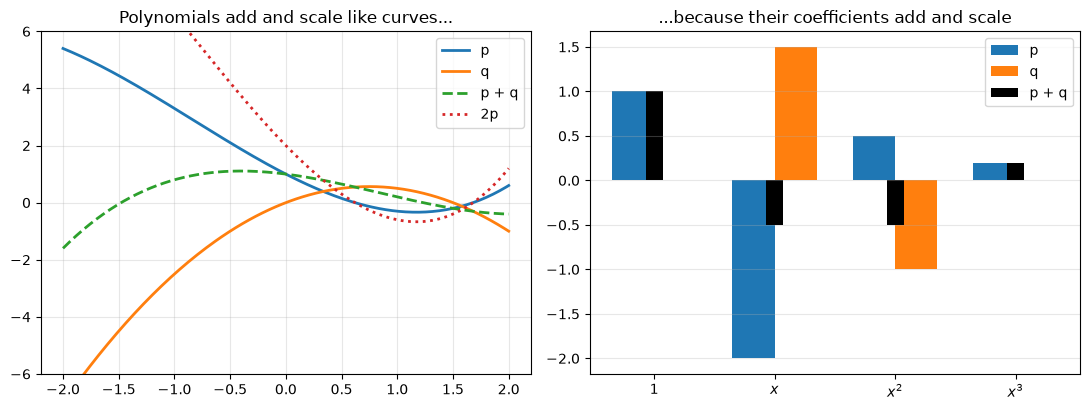

evaluate(p + q) == evaluate(p) + evaluate(q): True


In [9]:
def poly_eval(coeffs, x):
    """Evaluate a0 + a1 x + a2 x^2 + ... at x."""
    return sum(a * x ** i for i, a in enumerate(coeffs))

p = np.array([1.0, -2.0, 0.5, 0.2])     # 1 - 2x + 0.5x^2 + 0.2x^3
q = np.array([0.0,  1.5, -1.0, 0.0])    #     1.5x - x^2

xs = np.linspace(-2, 2, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for coeffs, label, style in [(p, "p", "-"), (q, "q", "-"),
                             (p + q, "p + q", "--"), (2 * p, "2p", ":")]:
    axes[0].plot(xs, poly_eval(coeffs, xs), style, label=label, lw=2)
axes[0].set_title("Polynomials add and scale like curves...")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(-6, 6)

width = 0.35
idx = np.arange(4)
axes[1].bar(idx - width / 2, p, width, label="p")
axes[1].bar(idx + width / 2, q, width, label="q")
axes[1].bar(idx, p + q, width * 0.4, color="k", label="p + q")
axes[1].set_xticks(idx, ["$1$", "$x$", "$x^2$", "$x^3$"])
axes[1].set_title("...because their coefficients add and scale")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

# The claim that makes the two panels the same picture, checked numerically:
same = np.allclose(poly_eval(p + q, xs), poly_eval(p, xs) + poly_eval(q, xs))
print("evaluate(p + q) == evaluate(p) + evaluate(q):", same)

## III.b Functions

Sample a function at 200 points and it becomes a vector in $\mathbb{R}^{200}$.
A linear combination of $\sin$ and $\cos$ is then just a weighted sum of two
long lists, and `centroid`, written for arrows, averages waveforms without
modification.

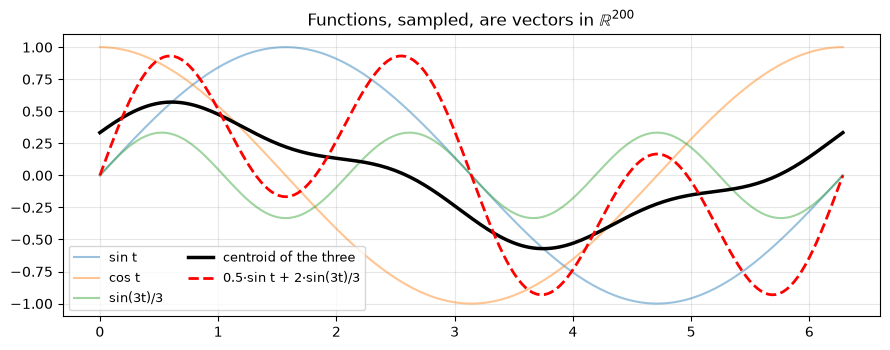

In [10]:
t = np.linspace(0, 2 * np.pi, 200)
f1, f2, f3 = np.sin(t), np.cos(t), np.sin(3 * t) / 3

plt.figure(figsize=(9, 3.6))
for vec, label in [(f1, "sin t"), (f2, "cos t"), (f3, "sin(3t)/3")]:
    plt.plot(t, vec, alpha=0.45, label=label)
plt.plot(t, centroid([f1, f2, f3]), "k", lw=2.5, label="centroid of the three")
plt.plot(t, 0.5 * f1 + 2.0 * f3, "r--", lw=2, label="0.5·sin t + 2·sin(3t)/3")
plt.title("Functions, sampled, are vectors in $\\mathbb{R}^{200}$")
plt.legend(fontsize=9, ncol=2); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## III.c Images

A 28×28 grayscale image is 784 numbers. Flatten it and it is a vector in
$\mathbb{R}^{784}$, a space we cannot draw, but one where addition and scaling
mean something you can *look at*.

The handwriting below is real, pulled from the Hugging Face Hub. `load_dataset`
fetches once and caches locally.

In [11]:
from datasets import load_dataset

mnist = load_dataset("ylecun/mnist")                       # cached after first run
train = mnist["train"]

N_PER_DIGIT = 500          # <- knob: how many examples to average per digit

labels = np.array(train["label"])
def digit_vectors(d, n=N_PER_DIGIT):
    """Return n images of digit d, each flattened to a 784-vector in [0, 1]."""
    idx = np.flatnonzero(labels == d)[:n]
    imgs = np.stack([np.array(im, dtype=np.float64) for im in train.select(idx)["image"]])
    return imgs.reshape(len(idx), -1) / 255.0

threes = digit_vectors(3)
eights = digit_vectors(8)
print("one image as a vector:", threes[0].shape, "| the collection:", threes.shape)

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


one image as a vector: (784,) | the collection: (500, 784)


### The centroid of five hundred threes

`centroid` is the same function that averaged three waveforms a moment ago. Here
it averages 500 points of $\mathbb{R}^{784}$, and the result, a blurry
archetypal 3, is a vector that no human ever wrote.

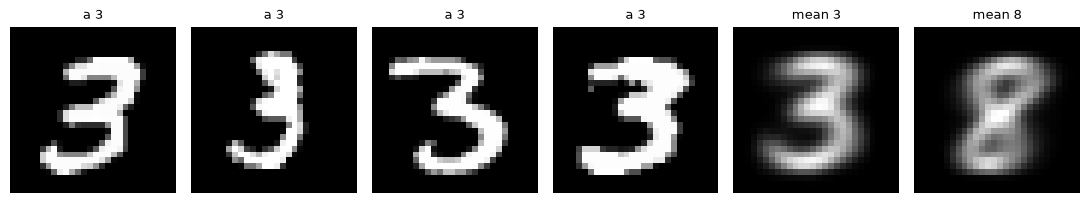

In [12]:
mean_three = centroid(list(threes))
mean_eight = centroid(list(eights))

fig, axes = plt.subplots(1, 6, figsize=(11, 2.4))
for ax, img in zip(axes[:4], threes[:4]):
    ax.imshow(img.reshape(28, 28), cmap="gray"); ax.set_title("a 3", fontsize=9)
axes[4].imshow(mean_three.reshape(28, 28), cmap="gray"); axes[4].set_title("mean 3", fontsize=9)
axes[5].imshow(mean_eight.reshape(28, 28), cmap="gray"); axes[5].set_title("mean 8", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

### The line between two images

Every point on the segment from $\mathbf{u}$ to $\mathbf{v}$ is
$(1-t)\mathbf{u} + t\mathbf{v}$, one addition and two scalings. In
$\mathbb{R}^{784}$ that segment is a sequence of images.

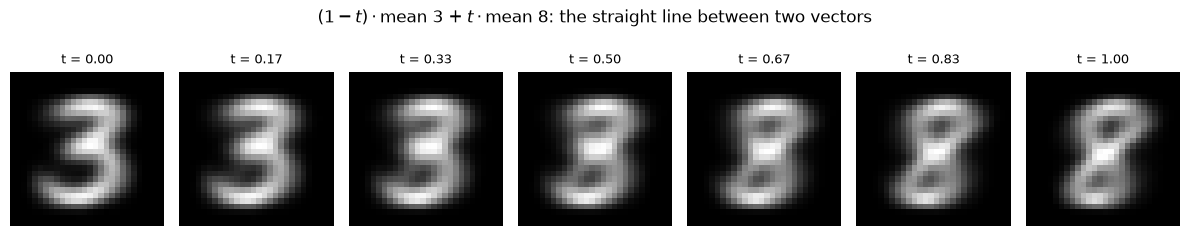

In [13]:
ts = np.linspace(0, 1, 7)
fig, axes = plt.subplots(1, len(ts), figsize=(12, 2.2))
for ax, tt in zip(axes, ts):
    blend = (1 - tt) * mean_three + tt * mean_eight
    ax.imshow(blend.reshape(28, 28), cmap="gray")
    ax.set_title(f"t = {tt:.2f}", fontsize=9); ax.axis("off")
fig.suptitle("$(1-t)\\cdot$mean 3 $+\\; t\\cdot$mean 8: the straight line between two vectors", y=1.06)
plt.tight_layout(); plt.show()

**Look closely at the middle frames, and do not let them slide by.** They are
not a 3 gradually *becoming* an 8. They are a double exposure, both digits
faintly superimposed, and for a stretch in the middle the image is neither digit.

That is an honest and important negative result. $\mathbb{R}^{784}$ is a genuine
vector space, so the straight line is guaranteed to exist. But *the set of
images that look like handwritten digits* is not closed under addition: add two
digits and you generally get something that is not a digit. Real data lives on a
curved, tangled subset of the space it is stored in, not on a flat one.

Linear algebra is the study of the flat parts. Its results are exact there, and
knowing precisely where flatness ends is part of using it well. "Flat piece of a
vector space" has a definition of its own, and that definition is Module IV.

---
# Module IV — Subspaces: Vector Spaces Inside Vector Spaces

## IV.a The three-part test

🧠 **The intuition.** A **subspace** is a subset you cannot escape from using
the only two moves available. Start anywhere inside it, add and scale as much as
you like, and you are still inside. Picture a plane through the origin sitting
inside $\mathbb{R}^3$: slide along it, double your position, reverse, and you
are still on the plane.

The origin is not optional. Scaling any member by $0$ gives $\mathbf{0}$, so
every subspace contains it. A plane that misses the origin is *not* a subspace,
which is the single most common trap in this material.

📐 **The math.** $W \subseteq V$ is a subspace of $V$ if:

1. $\mathbf{0} \in W$,
2. $\mathbf{u}, \mathbf{v} \in W \implies \mathbf{u} + \mathbf{v} \in W$ (closed under addition),
3. $\mathbf{v} \in W,\; c \in \mathbb{R} \implies c\mathbf{v} \in W$ (closed under scaling).

Nothing else needs checking. The other seven axioms are inherited from $V$,
since associativity does not stop being true because you restricted attention to
a subset.

💻 **The code.** A detector: draw random members, combine them, and see whether
the results are still members.

In [14]:
def is_subspace(sample, member, zero, n_trials=200, verbose=True, name=""):
    """Test the three subspace conditions by sampling. Prints the first counterexample."""
    print(name)
    checks = {"contains 0": member(zero), "closed under +": True, "closed under scaling": True}

    for _ in range(n_trials):
        u, v = sample(), sample()
        if not member(u + v):
            checks["closed under +"] = False
            if verbose:
                print(f"  counterexample (addition): {np.round(u, 2)} + {np.round(v, 2)} = {np.round(u + v, 2)}")
            break
    for _ in range(n_trials):
        v, c = sample(), rng.normal()
        if not member(c * v):
            checks["closed under scaling"] = False
            if verbose:
                print(f"  counterexample (scaling): {c:.2f} · {np.round(v, 2)} = {np.round(c * v, 2)}")
            break

    ok = all(checks.values())
    print(f"  -> {'SUBSPACE' if ok else 'NOT a subspace'}   "
          + "  ".join(f"[{k}: {'yes' if val else 'NO'}]" for k, val in checks.items()))
    print()
    return ok

## IV.b Four candidates in $\mathbb{R}^3$

| Candidate | What it looks like |
|---|---|
| $\{x : x_1 + x_2 + x_3 = 0\}$ | a plane through the origin |
| $\{x : x_1 + x_2 + x_3 = 1\}$ | the same plane, shifted off the origin |
| $\{x : x_i \ge 0\}$ | the positive octant, a solid corner of space |
| the union of the $x$- and $y$-axes | a pair of crossing lines |

Predict each verdict before running the cell. The last two are the instructive
ones: each satisfies exactly one of the two closure conditions.

In [15]:
TOL = 1e-9

# 1. plane through the origin: sample by taking any two free coordinates
is_subspace(name="{x : x1+x2+x3 = 0}   (plane through origin)",
            sample=lambda: (lambda a: np.array([a[0], a[1], -a[0] - a[1]]))(rng.normal(size=2)),
            member=lambda x: abs(x.sum()) < TOL,
            zero=np.zeros(3))

# 2. the same plane, shifted
is_subspace(name="{x : x1+x2+x3 = 1}   (parallel plane, misses origin)",
            sample=lambda: (lambda a: np.array([a[0], a[1], 1 - a[0] - a[1]]))(rng.normal(size=2)),
            member=lambda x: abs(x.sum() - 1) < TOL,
            zero=np.zeros(3))

# 3. the non-negative octant
is_subspace(name="{x : all xi >= 0}    (positive octant)",
            sample=lambda: np.abs(rng.normal(size=3)),
            member=lambda x: np.all(x >= -TOL),
            zero=np.zeros(3))

# 4. union of the x-axis and the y-axis
def on_axes(x):
    return (abs(x[1]) < TOL and abs(x[2]) < TOL) or (abs(x[0]) < TOL and abs(x[2]) < TOL)

_ = is_subspace(name="x-axis together with y-axis (two crossing lines)",
            sample=lambda: rng.normal() * (np.eye(3)[rng.integers(2)]),
            member=on_axes,
            zero=np.zeros(3))

{x : x1+x2+x3 = 0}   (plane through origin)
  -> SUBSPACE   [contains 0: yes]  [closed under +: yes]  [closed under scaling: yes]

{x : x1+x2+x3 = 1}   (parallel plane, misses origin)
  counterexample (addition): [ 0.86 -0.3   0.44] + [ 1.36 -0.43  0.07] = [ 2.22 -0.73  0.51]
  counterexample (scaling): 0.13 · [-0.12 -0.99  2.11] = [-0.01 -0.13  0.27]
  -> NOT a subspace   [contains 0: NO]  [closed under +: NO]  [closed under scaling: NO]

{x : all xi >= 0}    (positive octant)
  counterexample (scaling): -0.55 · [1.66 0.55 0.73] = [-0.92 -0.31 -0.41]
  -> NOT a subspace   [contains 0: yes]  [closed under +: yes]  [closed under scaling: NO]

x-axis together with y-axis (two crossing lines)
  counterexample (addition): [-0.   -0.18 -0.  ] + [-1. -0. -0.] = [-1.   -0.18 -0.  ]
  -> NOT a subspace   [contains 0: yes]  [closed under +: NO]  [closed under scaling: yes]



Read the counterexamples, not just the verdicts. The shifted plane fails
everything, because two vectors whose components sum to 1 each give a sum of 2,
and the origin is not on it. Shifted subspaces are common and useful objects,
called *affine* sets, and every line of best fit you have ever drawn is one, but
they are not subspaces and the theory in this course does not apply to them
directly.

The positive octant is closed under addition and dies on scaling, since
multiplying by any negative number takes you out of it. Closure under addition
alone is not enough. The pair of axes is the mirror image: every scalar multiple
of a point on an axis stays on that axis, but add a point on the $x$-axis to a
point on the $y$-axis and you land strictly between them, on neither. Closure
under scaling alone is not enough either.

## IV.c The subspace you get for free

🧠 **The intuition.** Take any set of vectors and ask: what is the smallest
subspace containing them? You must include all their scalar multiples, and then
all sums of those, and, reassuringly, that is where it stops. That collection is
automatically a subspace.

📐 **The math.** Given $\mathbf{v}_1, \dots, \mathbf{v}_k$, collect everything
of the form

$$ c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_k\mathbf{v}_k, \qquad c_1, \dots, c_k \in \mathbb{R} $$

Adding two vectors of this form gives another one, and so does scaling, so the
collection passes the subspace test by construction. And any subspace that
contains the $\mathbf{v}_i$ is forced to contain every such vector, which is
what "smallest" means. Chapter 2 gives this object a name and puts it to work.

💻 **The code.** Build it from two vectors in $\mathbb{R}^3$ and test it with the
same detector.

all combinations c1·a + c2·b


  -> SUBSPACE   [contains 0: yes]  [closed under +: yes]  [closed under scaling: yes]



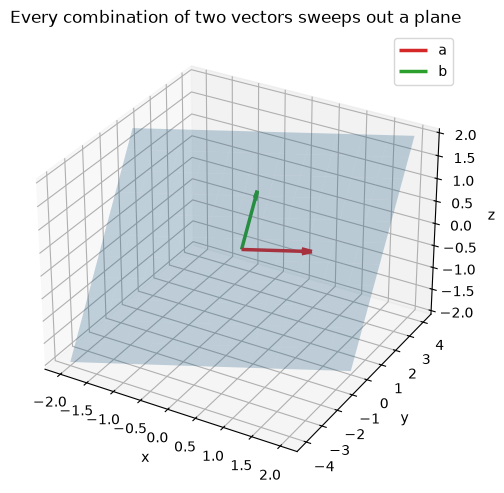

In [16]:
a = np.array([1.0, 1.0, 0.0])
b = np.array([0.0, 1.0, 1.0])

def random_combination():
    """A random point of the form c1·a + c2·b."""
    c1, c2 = rng.normal(size=2)
    return c1 * a + c2 * b

# membership test: is x expressible as c1·a + c2·b?  (least-squares residual ~ 0)
M = np.column_stack([a, b])
def in_plane(x):
    coeffs, *_ = np.linalg.lstsq(M, x, rcond=None)
    return np.linalg.norm(M @ coeffs - x) < 1e-9

is_subspace(name="all combinations c1·a + c2·b",
            sample=random_combination, member=in_plane, zero=np.zeros(3))

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
s = np.linspace(-2, 2, 12)
S, T = np.meshgrid(s, s)
P = S[..., None] * a + T[..., None] * b            # every point c1·a + c2·b
ax.plot_surface(P[..., 0], P[..., 1], P[..., 2], alpha=0.25, color="tab:blue")
for vec, color, label in [(a, "tab:red", "a"), (b, "tab:green", "b")]:
    ax.quiver(0, 0, 0, *vec, color=color, arrow_length_ratio=0.15, lw=2.5, label=label)
ax.set_title("Every combination of two vectors sweeps out a plane")
ax.legend(); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout(); plt.show()

That plane has a name, the **span** of $\{a, b\}$, and it is the subject of
Chapter 2. Notice what the picture already suggests: two vectors in
$\mathbb{R}^3$ swept out a *two*-dimensional plane, not all of $\mathbb{R}^3$.
Add a third vector and you might fill space, or you might get nothing new at all.
Which of those happens is the question that organises everything ahead.

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| Addition as a parallelogram, scaling as a stretch | Two operations, and there is no third: no vector×vector, no division |
| An eight-axiom checker | "Vector space" is a checklist, not a shape; anything passing it inherits the entire theory |
| Positive reals under $(\times, {}^{\wedge})$ passing all eight | Familiar spaces show up in unfamiliar costumes; logs are a change of coordinates |
| $c(x,y) = (cx, y)$ failing axiom 6 | Bending one rule breaks exactly one axiom, and the break is always concrete, a counterexample you can print |
| `centroid` running on polynomials, waveforms, and images | Write an algorithm once, in terms of $+$ and $\cdot$, and it runs on every vector space |
| The 3→8 image blend | A vector space is flat; real data is not. Linear algebra is the study of the flat parts |
| A subspace detector, and four candidates | Three tests: contains $\mathbf{0}$, closed under $+$, closed under scaling. Failing one is enough |

**Where the course goes from here.** The four-candidate experiment in Module IV
kept asking the same question in different clothes: *can I reach this vector
from those vectors?* Chapter 2 makes that question precise with two ideas:
**span** (everything you can reach) and **linear independence** (whether any of
your vectors were redundant to begin with).

Those two, together, produce the most important concept in the subject: a
**basis**, which is Chapter 3.